In [108]:
import torch
import matplotlib.pyplot as plt
from scipy.stats import lognorm
import seaborn as sns
import numpy as np

from deep_hedging.gbm import simulate_gbm
from deep_hedging.engine import pnl
from deep_hedging.payoffs import call_payoff

In [109]:
S0=100
mu=0.00
sigma=0.2
T=1
n_steps=100
n_paths=10_000

K = 120.0 # strike price


p0 = 2.14 # comes from BS pricing, chosen to validate:  E[delta_0 strategy] = 0

def _gbm(seed = 0):
    g = torch.Generator().manual_seed(seed)
    return g

In [110]:
t, S = simulate_gbm(S0, mu, sigma, T, n_steps, n_paths, generator=_gbm(seed=0))

In [111]:
payoff = call_payoff(K, S[:, -1, :])

In [112]:
# strategy 1:
delta_leak = torch.sign(S[:, 1:, :] - S[:, :-1, :]) #leaking delta policy
#strategy 2:
delta_lag = torch.sign(S[:, :-1, :].diff(dim=1, prepend=S[:, :1, :])) #lagging delta policy
#strategy 3:
delta_0 = torch.zeros_like(S[:, :-1, :])
#strategy 4:
delta_1 = torch.ones_like(S[:, :-1, :]) # if c = 0 mean should be p0 - payoff + S_T - S0


strategies = {
    #payoff, S, delta, p0, c=0.0 pnl parameters
    "leak": [payoff, S, delta_leak, p0, 0.0],
    "lag": [payoff, S, delta_lag, p0, 0.0],
    "all_0": [payoff, S, delta_0, p0, 0.0],
    "all_1": [payoff, S, delta_1, p0, 0.0]
}


KeyboardInterrupt: 

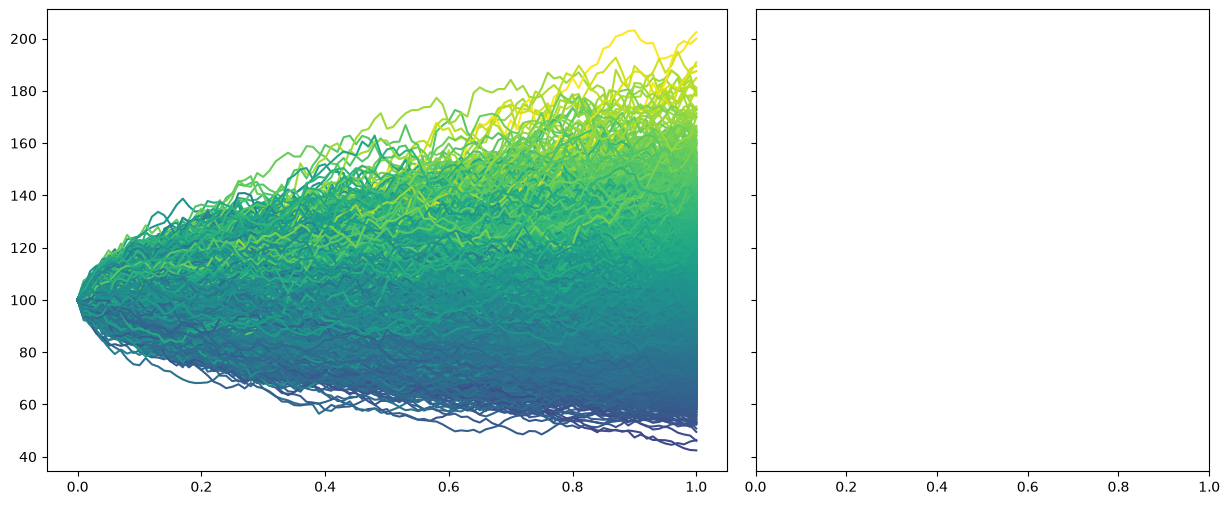

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), sharey=True, gridspec_kw={'width_ratios': [3, 2], 'wspace': 0.05})

axe_paths = axes[0]

max_S = np.max(S[:, -1, :])

for i in range(n_paths):
    
    #if S[i][-1] > 150:
    #    colors = plt.cm.viridis(i / n_paths)
    #else:
    #    colors = plt.cm.plasma(i / n_paths)
    
    colors = plt.cm.viridis(S[i, -1] / max_S) 
    axe_paths.plot(t, S[i], color=colors)
    
axe_paths.axhline(K, color="red", linestyle="--", label=f"Strike Price = {K}")
axe_paths.set_title(f"Geometric Brownian Motion Simulation (n_paths={n_paths})")
axe_paths.set_xlabel("Time")
axe_paths.set_ylabel("Stock Price")
axe_paths.legend()

axe_distribution = axes[1]
count, bins, patches = axe_distribution.hist(S[:, -1, :], bins=50, density=True, orientation="horizontal", color='lightblue', edgecolor='black')

log_mu = np.log(S0) + (mu - 0.5 * sigma**2) * T
log_sigma = sigma * np.sqrt(T)

y = np.linspace(min(S[:, -1, :]), mas_S, 500)

lognorm_pdf = lognorm.pdf(y, s=log_sigma, scale=np.exp(log_mu))
axe_distribution.plot(lognorm_pdf, y, color='orange', linewidth=2, label='Lognormal')
axe_distribution.axhline(K, color="red", linestyle="--", label=f"Strike Price = {K}")
axe_distribution.set_title("Stock Price Distribution at T")
axe_distribution.set_xlabel("Density")
axe_distribution.set_ylabel("Nbr of Paths")
axe_distribution.legend()

plt.show()

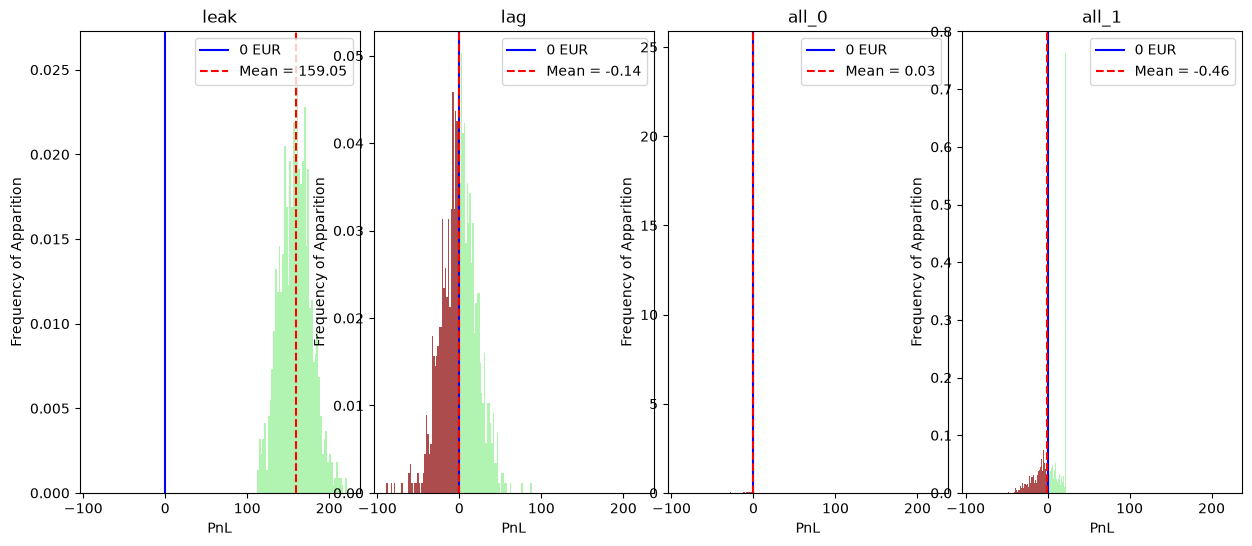

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=len(strategies), figsize=(15, 6), sharex=True, gridspec_kw={'wspace': 0.05})

for (strategy_name, params), ax in zip(strategies.items(), axes):
    pl = pnl(*params)
    pl_np = np.asarray(pl)
    
    losses = pl_np[pl_np < 0]
    profits = pl_np[pl_np >= 0]
    
    ax.hist(losses, bins=50, density=True, alpha=0.7, color='darkred')
    ax.hist(profits, bins=50, density=True, alpha=0.7, color='lightgreen')


    ax.axvline(0, color='blue', linestyle='-', linewidth=1.5, label='0 EUR')
    ax.axvline(pl_np.mean(), color="red", linestyle="--", label=f"Mean = {pl_np.mean():.2f}")
    
    ax.set_title(f"{strategy_name}")
    ax.set_xlabel("PnL")
    ax.set_ylabel("Frequency of Apparition")
    ax.legend()

plt.show()

In [ ]:
# for the strategy delta = 1:
pnl_delta_1 = pnl(payoff, S, delta_1, p0, 0.0)

expected_mean = p0 - payoff + S[:, -1, 0] - S0
print(f"how much one deviates from the other : {(pnl_delta_1 - expected_mean).abs().max()}")

print(f"Mean: {pnl_delta_1.mean():.2f}, Std: {pnl_delta_1.std():.2f}")

how much one deviates from the other : 3.814697265625e-06
Mean: -0.46, Std: 16.16


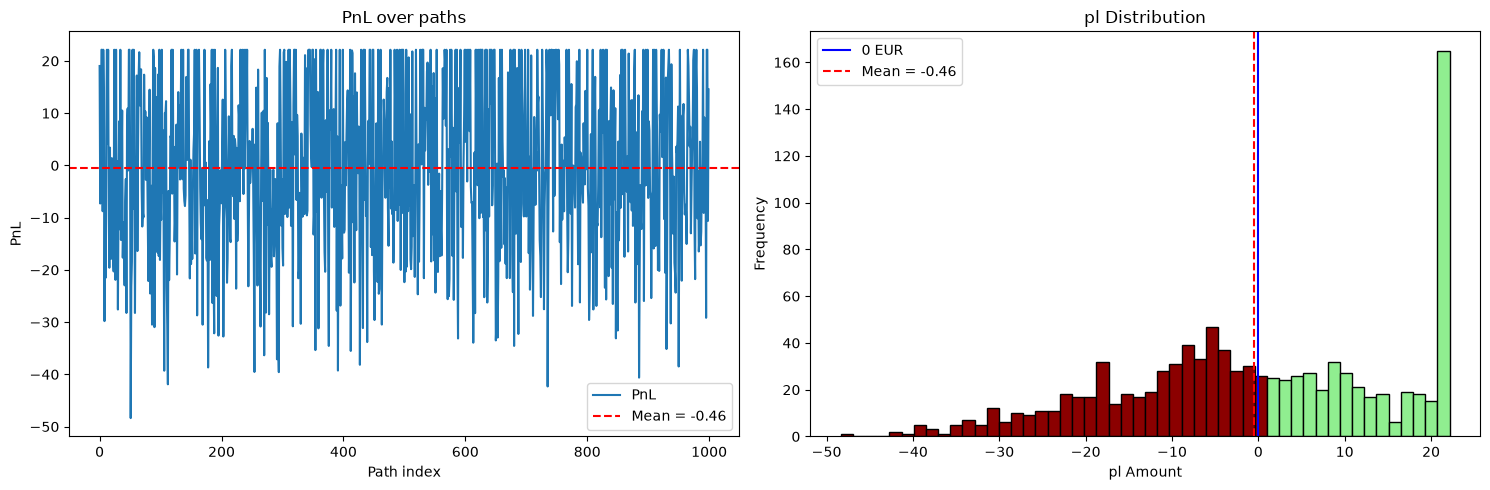

In [ ]:
#view one strategy at the time

pl_np = np.asarray(pnl_delta_1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(pl_np, label="PnL")
axes[0].axhline(pl_np.mean(), color="red", linestyle="--", label=f"Mean = {pl_np.mean():.2f}")
axes[0].set_title("PnL over paths")
axes[0].set_xlabel("Path index")
axes[0].set_ylabel("PnL")
axes[0].legend()

counts, bins, patches = axes[1].hist(pl_np, bins=50, edgecolor='black')

for patch in patches:
    if patch.get_x() < 0:
        patch.set_facecolor('darkred')  # Loss
    else:
        patch.set_facecolor('lightgreen')  # Profit

axes[1].axvline(0, color='blue', linestyle='-', linewidth=1.5, label='0 EUR')
axes[1].axvline(pl_np.mean(), color="red", linestyle="--", label=f"Mean = {pl_np.mean():.2f}")
axes[1].set_title("pl Distribution")
axes[1].set_xlabel("pl Amount")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.show()